In [74]:
# ==========================================================
# step 1
# ==========================================================

import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

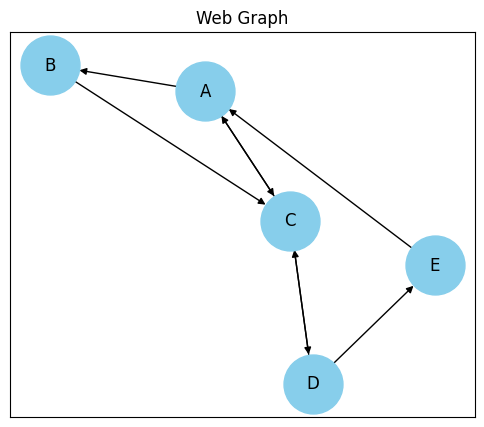

In [75]:
# ==========================================================
# step 2 : ساخت گراف
# ==========================================================

import networkx as nx
import matplotlib.pyplot as plt

G = nx.DiGraph()

edges = [
    ("A","B"),
    ("A","C"),
    ("B","C"),
    ("C","A"),
    ("C","D"),
    ("D","C"),
    ("D","E"),
    ("E","A")
]

G.add_edges_from(edges)

plt.figure(figsize=(6,5))

nx.draw_networkx(
    G,
    node_color="skyblue",
    node_size=1800,
    arrows=True
)

plt.title("Web Graph")

plt.show()

In [76]:
# ==========================================================
# Step 3 : Adjacency Matrix
# ==========================================================

import numpy as np

nodes = list(G.nodes())

adj_matrix = nx.to_numpy_array(
    G,
    nodelist=nodes,
    dtype=int
)

print("Nodes:")
print(nodes)

print("\nAdjacency Matrix:\n")
print(adj_matrix)

Nodes:
['A', 'B', 'C', 'D', 'E']

Adjacency Matrix:

[[0 1 1 0 0]
 [0 0 1 0 0]
 [1 0 0 1 0]
 [0 0 1 0 1]
 [1 0 0 0 0]]


In [77]:
# ==========================================================
# Step 4 : Out Degree
# ==========================================================

out_degree = adj_matrix.sum(axis=1)

print("Out Degree of each node:\n")

for node, degree in zip(nodes, out_degree):
    print(f"{node} : {degree}")

Out Degree of each node:

A : 2
B : 1
C : 2
D : 2
E : 1


In [78]:
# ==========================================================
# Step 5 : Transition Matrix
# ==========================================================

transition_matrix = adj_matrix.astype(float)

for i in range(len(nodes)):
    if out_degree[i] != 0:
        transition_matrix[i] /= out_degree[i]

print("Transition Matrix:\n")
print(np.round(transition_matrix,3))

Transition Matrix:

[[0.  0.5 0.5 0.  0. ]
 [0.  0.  1.  0.  0. ]
 [0.5 0.  0.  0.5 0. ]
 [0.  0.  0.5 0.  0.5]
 [1.  0.  0.  0.  0. ]]


In [79]:
# ==========================================================
# Step 6.1 : PageRank Parameters
# ==========================================================

n = len(nodes)

d = 0.85

max_iterations = 100

tolerance = 1e-6

print("Number of nodes :", n)
print("Damping Factor :", d)
print("Maximum Iterations :", max_iterations)
print("Tolerance :", tolerance)

Number of nodes : 5
Damping Factor : 0.85
Maximum Iterations : 100
Tolerance : 1e-06


In [80]:
# ==========================================================
# Step 6.2 : Initial Rank Vector
# ==========================================================

rank = np.ones(n) / n

print("Initial Rank Vector:\n")
print(rank)

Initial Rank Vector:

[0.2 0.2 0.2 0.2 0.2]


In [81]:
# ==========================================================
# Step 6.3 : Power Iteration
# ==========================================================

for iteration in range(max_iterations):

    new_rank = (
        d * transition_matrix.T @ rank
        + (1 - d) / n
    )

    error = np.linalg.norm(new_rank - rank, 1)

    print(f"Iteration {iteration+1:2d}  Error = {error:.8f}")

    if error < tolerance:
        print("\nConverged Successfully!")
        break

    rank = new_rank.copy()

Iteration  1  Error = 0.51000000
Iteration  2  Error = 0.21675000
Iteration  3  Error = 0.18423750
Iteration  4  Error = 0.15660187
Iteration  5  Error = 0.08874106
Iteration  6  Error = 0.03771495
Iteration  7  Error = 0.01602885
Iteration  8  Error = 0.00681226
Iteration  9  Error = 0.00506662
Iteration 10  Error = 0.00430663
Iteration 11  Error = 0.00287621
Iteration 12  Error = 0.00155577
Iteration 13  Error = 0.00066120
Iteration 14  Error = 0.00028101
Iteration 15  Error = 0.00011943
Iteration 16  Error = 0.00010152
Iteration 17  Error = 0.00008629
Iteration 18  Error = 0.00005501
Iteration 19  Error = 0.00002783
Iteration 20  Error = 0.00001183
Iteration 21  Error = 0.00000503
Iteration 22  Error = 0.00000265
Iteration 23  Error = 0.00000225
Iteration 24  Error = 0.00000173
Iteration 25  Error = 0.00000102
Iteration 26  Error = 0.00000048

Converged Successfully!


In [82]:
# ==========================================================
# Step 7 : Final PageRank Scores
# ==========================================================

print("\nFinal PageRank Scores\n")

for node, score in zip(nodes, rank):
    print(f"{node} : {score:.6f}")


Final PageRank Scores

A : 0.257445
B : 0.139414
C : 0.330333
D : 0.170391
E : 0.102416


In [83]:
# ==========================================================
# Step 8 : Sort Pages by PageRank
# ==========================================================

pagerank_result = list(zip(nodes, rank))

pagerank_result.sort(
    key=lambda x: x[1],
    reverse=True
)

print("=" * 40)
print("PageRank Result")
print("=" * 40)

for i, (node, score) in enumerate(pagerank_result, start=1):
    print(f"{i}. {node} : {score:.6f}")

PageRank Result
1. C : 0.330333
2. A : 0.257445
3. D : 0.170391
4. B : 0.139414
5. E : 0.102416


In [84]:
# ==========================================================
# Step 9 : Verify Rank Sum
# ==========================================================

print("Sum of all PageRank values:")
print(rank.sum())

Sum of all PageRank values:
1.0000000000000002


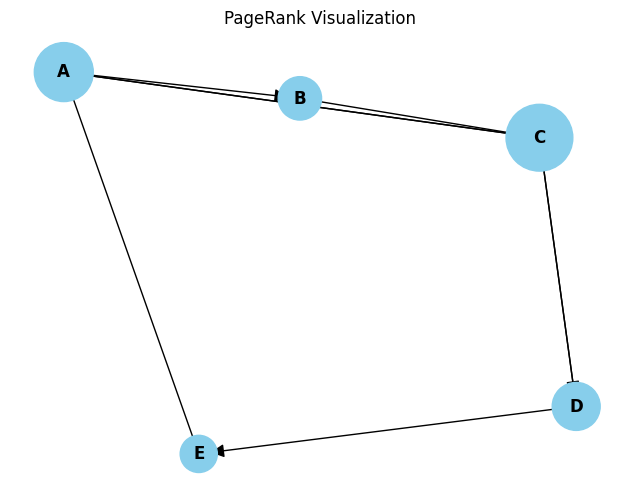

In [85]:
# ==========================================================
# Step 10 : Draw Graph with PageRank
# ==========================================================

plt.figure(figsize=(8,6))

position = nx.spring_layout(
    G,
    seed=42
)

sizes = rank * 7000

nx.draw_networkx_nodes(
    G,
    position,
    node_size=sizes,
    node_color="skyblue"
)

nx.draw_networkx_edges(
    G,
    position,
    arrows=True,
    arrowsize=20
)

nx.draw_networkx_labels(
    G,
    position,
    font_size=12,
    font_weight="bold"
)

plt.title("PageRank Visualization")

plt.axis("off")

plt.show()

In [86]:
# ==========================================================
# Step 11 : Compare with NetworkX
# ==========================================================

nx_rank = nx.pagerank(
    G,
    alpha=0.85
)

print("NetworkX PageRank\n")

for node, score in sorted(
    nx_rank.items(),
    key=lambda x: x[1],
    reverse=True
):
    print(f"{node} : {score:.6f}")

NetworkX PageRank

C : 0.330333
A : 0.257445
D : 0.170391
B : 0.139414
E : 0.102416


In [87]:
def build_graph(edges):

    graph = nx.DiGraph()

    graph.add_edges_from(edges)

    return graph

In [88]:
edges = [
    ("A","B"),
    ("A","C"),
    ("B","C"),
    ("C","A"),
    ("C","D"),
    ("D","C"),
    ("D","E"),
    ("E","A")
]

G = build_graph(edges)

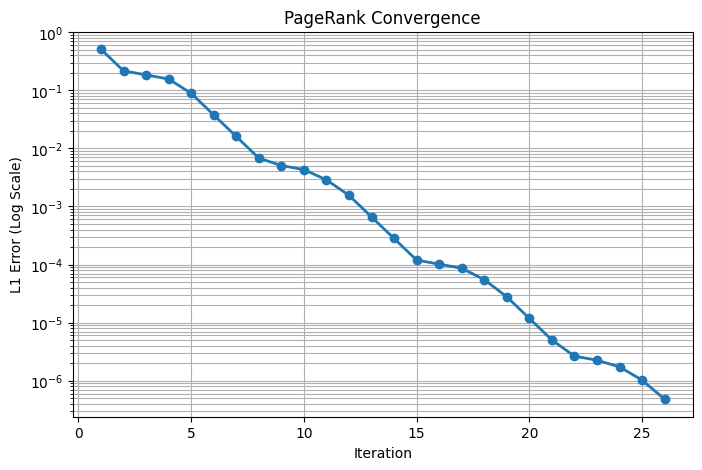

In [89]:
# ==========================================================
# Step 13 : Convergence Analysis (Log Scale)
# ==========================================================

errors = []

rank_temp = np.ones(n) / n

for iteration in range(max_iterations):

    new_rank = (
        d * transition_matrix.T @ rank_temp
        + (1 - d) / n
    )

    error = np.linalg.norm(new_rank - rank_temp, 1)

    errors.append(error)

    if error < tolerance:
        break

    rank_temp = new_rank.copy()

plt.figure(figsize=(8,5))

plt.semilogy(
    range(1, len(errors)+1),
    errors,
    marker='o',
    linewidth=2
)

plt.title("PageRank Convergence")

plt.xlabel("Iteration")

plt.ylabel("L1 Error (Log Scale)")

plt.grid(True, which="both")

plt.show()